In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import PIL
import random
import seaborn as sns
from pathlib import Path
import cv2


In [2]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define paths
DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed\v1"
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT, "VALIDATION")
TEST_DIR = os.path.join(DATA_ROOT, "TEST")

# Create output directory
OUTPUT_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\output"
OUTPUT_DIR =os.path.join(OUTPUT_ROOT, "v1")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define class labels
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}


Random seed set to 42
Using device: cuda:0


## Data Exploration

In [3]:


def explore_dataset(data_dir, title):
    """Explore the dataset and visualize class distribution."""
    class_counts = {cls: 0 for cls in classes}
    file_paths = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(files)
            
            for file in files:
                file_paths.append(os.path.join(class_path, file))
                labels.append(class_to_idx[class_name])
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} samples")
    print(f"  Total: {sum(class_counts.values())} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"{title} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    for i, count in enumerate(class_counts.values()):
        plt.text(i, count + 5, str(count), ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title.lower()}_class_distribution.png"))
    plt.close()
    
    return file_paths, labels, class_counts

# Explore all datasets
train_files, train_labels, train_counts = explore_dataset(TRAIN_DIR, "Training")
val_files, val_labels, val_counts = explore_dataset(VAL_DIR, "Validation")
test_files, test_labels, test_counts = explore_dataset(TEST_DIR, "Test")


Training Dataset Statistics:
  SOBER: 5644 samples
  DRUNK: 2489 samples
  Total: 8133 samples

Validation Dataset Statistics:
  SOBER: 4113 samples
  DRUNK: 1706 samples
  Total: 5819 samples

Test Dataset Statistics:
  SOBER: 2370 samples
  DRUNK: 2025 samples
  Total: 4395 samples


## Data Visualization

In [4]:


def visualize_spectrograms(file_paths, labels, num_samples=5, save_path=None):
    """Visualize sample spectrograms from each class"""
    # Get sample images from each class
    samples_by_class = {cls: [] for cls in classes}
    for path, label in zip(file_paths, labels):
        class_name = idx_to_class[label]
        if len(samples_by_class[class_name]) < num_samples:
            samples_by_class[class_name].append(path)
    
    # Create subplot grid
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        for j, img_path in enumerate(samples_by_class[class_name]):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_name}")
            axes[i, j].axis('off')
    
    plt.suptitle("Sample Spectrogram Images")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.close()

# Visualize sample spectrograms
visualize_spectrograms(
    train_files, 
    train_labels, 
    num_samples=5, 
    save_path=os.path.join(OUTPUT_DIR, "sample_spectrograms.png")
)

## Dataset 

In [5]:

class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label



## Data Preparation

In [6]:

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize datasets

train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()  # Normalize
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders
BATCH_SIZE = 100
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Model

In [7]:
def resnet18_classifier():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze deeper layers for fine-tuning
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace classifier head
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 1)  # Output for binary classification
    )

    return model.to(device)



## Training Set Up

In [8]:

model = resnet18_classifier()
initial_lr = 3e-4 # Start with a very small lr
patience = 5   # Early stopping patience
num_epochs =10

# Use class distribution from training data to set pos_weight
# train_counts = {'SOBER': 5189, 'DRUNK': 2281}
pos_weight = torch.tensor([train_counts['SOBER'] / (train_counts['DRUNK'])]).to(device)

# Use BCEWithLogitsLoss with pos_weight to handle imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer for fine-tuned layers only
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=initial_lr , weight_decay=1e-4)


# Learning rate scheduler — Reduce on plateau (e.g., validation loss)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=0.5)


print("\nTraining setup:")
print("Model: ResNet18 pretrained")
print("Optimizer: Adam(lr=0.001, weight_decay=1e-4)")
print("LR scheduler: ReduceLROnPlateau (on val loss)")
print(f"Using pos_weight = {pos_weight.item():.4f}")


Training setup:
Model: ResNet18 pretrained
Optimizer: Adam(lr=0.001, weight_decay=1e-4)
LR scheduler: ReduceLROnPlateau (on val loss)
Using pos_weight = 2.2676


In [9]:


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics

## Training


Epoch 1/10
----------


Training: 100%|██████████| 82/82 [01:29<00:00,  1.09s/it]


Train Loss: 0.8166 | Val Loss: 1.2055
Train Acc: 0.7011 | Val Acc: 0.5522
Train UAR: 0.7008 | Val UAR: 0.5933
Validation Confusion Matrix:
[[2031 2082]
 [ 524 1182]]
Saved new best model (based on UAR)!

Epoch 2/10
----------


Training: 100%|██████████| 82/82 [01:35<00:00,  1.16s/it]


Train Loss: 0.4894 | Val Loss: 1.5126
Train Acc: 0.8545 | Val Acc: 0.5913
Train UAR: 0.8546 | Val UAR: 0.5957
Validation Confusion Matrix:
[[2407 1706]
 [ 672 1034]]
Saved new best model (based on UAR)!

Epoch 3/10
----------


...

Train Loss: 0.0389 | Val Loss: 2.6572
Train Acc: 0.9915 | Val Acc: 0.6951
Train UAR: 0.9916 | Val UAR: 0.5964
Validation Confusion Matrix:
[[3435  678]
 [1096  610]]
No improvement in UAR for 1/5 epochs

Epoch 9/10
----------


Training: 100%|██████████| 82/82 [00:25<00:00,  3.20it/s]


Train Loss: 0.0299 | Val Loss: 2.6253
Train Acc: 0.9924 | Val Acc: 0.6871
Train UAR: 0.9923 | Val UAR: 0.6087
Validation Confusion Matrix:
[[3283  830]
 [ 991  715]]
No improvement in UAR for 2/5 epochs

Epoch 10/10
----------


Training: 100%|██████████| 82/82 [00:23<00:00,  3.52it/s]


Train Loss: 0.0123 | Val Loss: 2.8699
Train Acc: 0.9973 | Val Acc: 0.6771
Train UAR: 0.9973 | Val UAR: 0.5997
Validation Confusion Matrix:
[[3236  877]
 [1002  704]]
No improvement in UAR for 3/5 epochs

Training completed. Loaded best model weights.


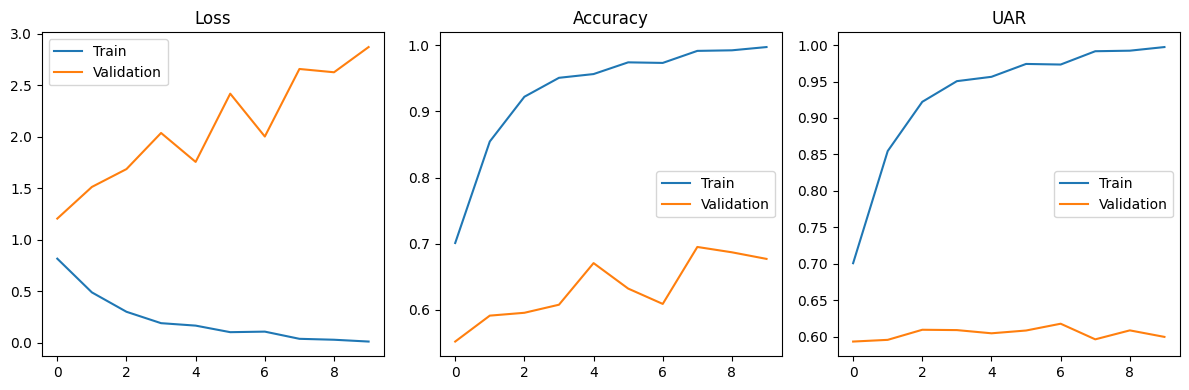


Final Test Results:
Accuracy: 0.6018
UAR: 0.6084
Confusion Matrix:
[[1244 1126]
 [ 624 1401]]


In [10]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        # scheduler.step()
        scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR,"best_model.pth"))
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")) )
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs,
    patience  # Stop if no improvement for 10 epochs
)


# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"training_curves.png"))
plt.show()


# Load best model and evaluate on test set
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")) )
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

## Evaluation


Final Test Results:
Loss: 2.1396
Accuracy: 0.6018
UAR: 0.6084
Confusion Matrix:
[[1244 1126]
 [ 624 1401]]


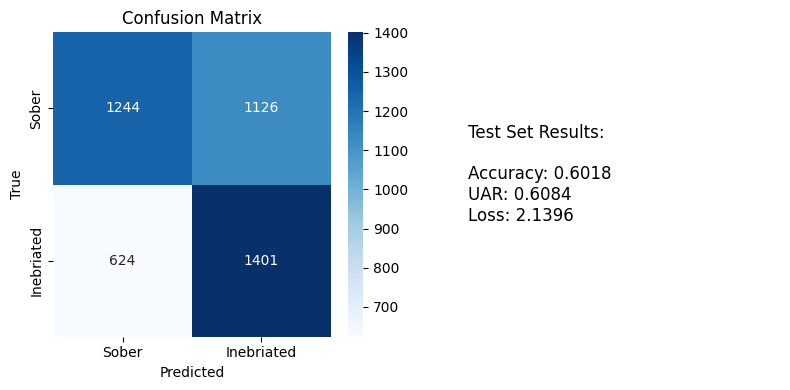

In [11]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        "Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig("output/test_results.png")
    plt.show()

# Load best model and evaluate
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

# Plot results
plot_results(test_metrics, ['Sober', 'Inebriated'])  # Replace with your actual class names
